# Inference Optimization Evaluation

Analyze post-training inference optimization results for PaDiM, PatchCore, FastFlow, and WinCLIP zero-shot.

This notebook reads benchmark artifacts only. It does not run training, test, export, or inference.

In [40]:
from pathlib import Path
import ast
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 160)

RESULT_DIR = Path("/workspace/checkpoints/anomaly_detection/inference_optimization/visa")
SUMMARY_PATH = RESULT_DIR / "summary.csv"
ERRORS_PATH = RESULT_DIR / "errors.csv"
ENV_PATH = RESULT_DIR / "environment.json"

EXPECTED_MODELS = ["padim", "patchcore", "fastflow", "winclip_zeroshot"]
EXPECTED_VARIANTS = [
    "baseline_eager_fp32",
    "eager_amp_fp16",
    "torch_compile_fp32",
    "torch_compile_amp_fp16",
    "onnxruntime_cuda_fp32",
    "onnxruntime_tensorrt_fp32",
    "onnxruntime_tensorrt_fp16",
]

assert SUMMARY_PATH.exists(), f"summary.csv not found: {SUMMARY_PATH}"
summary = pd.read_csv(SUMMARY_PATH)
errors = pd.read_csv(ERRORS_PATH) if ERRORS_PATH.exists() else pd.DataFrame(columns=["model", "category", "variant", "error_type", "error"])
environment = json.loads(ENV_PATH.read_text()) if ENV_PATH.exists() else {}

summary["latency_ms_per_image"] = summary["mean_inference_sec"] / summary["total_images"] * 1000.0
summary["latency_std_ms_per_image"] = summary["std_inference_sec"] / summary["total_images"] * 1000.0

summary.head()


,model,category,variant,status,total_images,mean_inference_sec,std_inference_sec,images_per_sec,timings_sec,image_auroc,image_ap,best_f1,best_threshold,num_examples,positive_ratio,pixel_auroc,pixel_ap,pixel_best_f1,pixel_best_threshold,speedup_vs_baseline,best_f1_delta_vs_baseline,pixel_best_f1_delta_vs_baseline,latency_ms_per_image,latency_std_ms_per_image
0,padim,candle,baseline_eager_fp32,ok,200,0.344977,0.002667,579.749291,"[0.3483792129554786, 0.3420960200019181, 0.34292995603755116, 0.3480134480050765, 0.343464887002483]",0.94140,0.927651,0.893023,63.464594,200,0.5,0.989038,0.184658,0.249001,86.909963,1.000000,0.0,0.000000,1.724884,0.013336
1,padim,candle,eager_amp_fp16,ok,200,0.219887,0.000993,909.558219,"[0.21912983898073435, 0.21914874104550108, 0.22029507701518014, 0.2191944859805517, 0.2216667030006647]",0.94145,0.927992,0.893023,63.404523,200,0.5,0.989044,0.184467,0.248671,86.770179,1.568882,0.0,-0.000331,1.099435,0.004966
2,padim,candle,torch_compile_fp32,ok,200,0.240178,0.007557,832.715677,"[0.25501058698864654, 0.23915027896873653, 0.23482265998609364, 0.23573889100225642, 0.23616766795748845]",0.94140,0.927651,0.893023,63.461359,200,0.5,0.989040,0.184657,0.249025,86.906878,1.436338,0.0,0.000024,1.200890,0.037784
3,padim,candle,torch_compile_amp_fp16,ok,200,0.144038,0.003385,1388.518690,"[0.15025828796206042, 0.1417919640080072, 0.14503536303527653, 0.14189059002092108, 0.14121575700119138]",0.94140,0.927950,0.893023,63.429177,200,0.5,0.989048,0.184505,0.248719,86.772574,2.395033,0.0,-0.000282,0.720192,0.016927
4,padim,candle,onnxruntime_cuda_fp32,ok,200,0.346766,0.001315,576.758537,"[0.3453423579921946, 0.34660092496778816, 0.34721402096329257, 0.3456403480377048, 0.3490301719866693]",0.94130,0.927842,0.893023,62.375399,200,0.5,0.989003,0.184465,0.248753,87.756393,0.994841,0.0,-0.000248,1.733828,0.006576


## Run Completeness

Check whether every model and optimization variant finished successfully. Missing entries usually mean the variant failed and should be inspected in `errors.csv`.

In [41]:
expected = pd.MultiIndex.from_product([EXPECTED_MODELS, EXPECTED_VARIANTS], names=["model", "variant"]).to_frame(index=False)
status = expected.merge(summary[["model", "variant", "status"]], on=["model", "variant"], how="left")
status = status.merge(errors[["model", "variant", "error_type", "error"]], on=["model", "variant"], how="left")
status["result"] = np.where(status["status"].eq("ok"), "ok", np.where(status["error_type"].notna(), "failed", "missing"))

status_matrix = status.pivot(index="model", columns="variant", values="result").loc[EXPECTED_MODELS, EXPECTED_VARIANTS]
status_matrix

variant,baseline_eager_fp32,eager_amp_fp16,torch_compile_fp32,torch_compile_amp_fp16,onnxruntime_cuda_fp32,onnxruntime_tensorrt_fp32,onnxruntime_tensorrt_fp16
model,,,,,,,
padim,ok,ok,ok,ok,ok,ok,ok
patchcore,ok,ok,ok,ok,ok,failed,ok
fastflow,ok,ok,ok,ok,ok,ok,ok
winclip_zeroshot,ok,ok,ok,ok,ok,ok,ok


In [42]:
if len(errors):
    display(errors[["model", "variant", "error_type", "error"]])
else:
    print("No errors.csv entries found.")

print(f"Successful rows: {len(summary)} / expected {len(EXPECTED_MODELS) * len(EXPECTED_VARIANTS)}")

,model,variant,error_type,error
0,patchcore,onnxruntime_tensorrt_fp32,RuntimeError,Error in execution: Non-zero status code returned while running TRTKernel_graph_main_graph_13614309082846495642_0 node. Name:'TensorrtExecutionProvider_TRTK...


Successful rows: 27 / expected 28


## Environment

Record the runtime context because TensorRT and ONNX Runtime behavior is highly environment-dependent.

In [43]:
environment

{'python': '3.11.15 (main, Apr  7 2026, 02:24:41) [GCC 14.2.0]',
 'platform': 'Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.41',
 'device': 'cuda',
 'torch_cuda_available': True,
 'torch_cuda_version': '12.8',
 'packages': {'torch': '2.10.0',
  'anomalib': '2.3.3',
  'onnx': '1.21.0',
  'onnxruntime-gpu': '1.24.4',
  'onnxscript': '0.6.2',
  'tensorrt': None,
  'tensorrt-cu12': '10.16.1.11'},
 'gpu_name': 'NVIDIA GeForce RTX 4090',
 'gpu_capability': [8, 9],
 'onnxruntime_available_providers': ['TensorrtExecutionProvider',
  'CUDAExecutionProvider',
  'CPUExecutionProvider']}

## Speed Overview

Use absolute per-image inference latency for deployment decisions. `latency_ms_per_image` is derived from the full test-pass model compute time divided by the number of evaluated images, then converted to milliseconds.


In [44]:
speed_cols = [
    "model",
    "variant",
    "total_images",
    "mean_inference_sec",
    "std_inference_sec",
    "latency_ms_per_image",
    "latency_std_ms_per_image",
]
speed_table = summary[speed_cols].sort_values(["model", "latency_ms_per_image"], ascending=[True, True]).reset_index(drop=True)
speed_table


,model,variant,total_images,mean_inference_sec,std_inference_sec,latency_ms_per_image,latency_std_ms_per_image
0,fastflow,onnxruntime_tensorrt_fp16,200,0.166406,0.091404,0.832030,0.457020
1,fastflow,torch_compile_fp32,200,0.308309,0.004516,1.541543,0.022579
2,fastflow,onnxruntime_tensorrt_fp32,200,0.321486,0.034315,1.607432,0.171574
3,fastflow,torch_compile_amp_fp16,200,0.353369,0.000089,1.766843,0.000447
4,fastflow,eager_amp_fp16,200,0.354050,0.004156,1.770252,0.020782
5,fastflow,baseline_eager_fp32,200,0.517661,0.000544,2.588305,0.002719
6,fastflow,onnxruntime_cuda_fp32,200,0.571402,0.019114,2.857009,0.095570
7,padim,onnxruntime_tensorrt_fp16,200,0.084575,0.008381,0.422876,0.041904
8,padim,torch_compile_amp_fp16,200,0.144038,0.003385,0.720192,0.016927
9,padim,onnxruntime_tensorrt_fp32,200,0.198325,0.017105,0.991624,0.085525


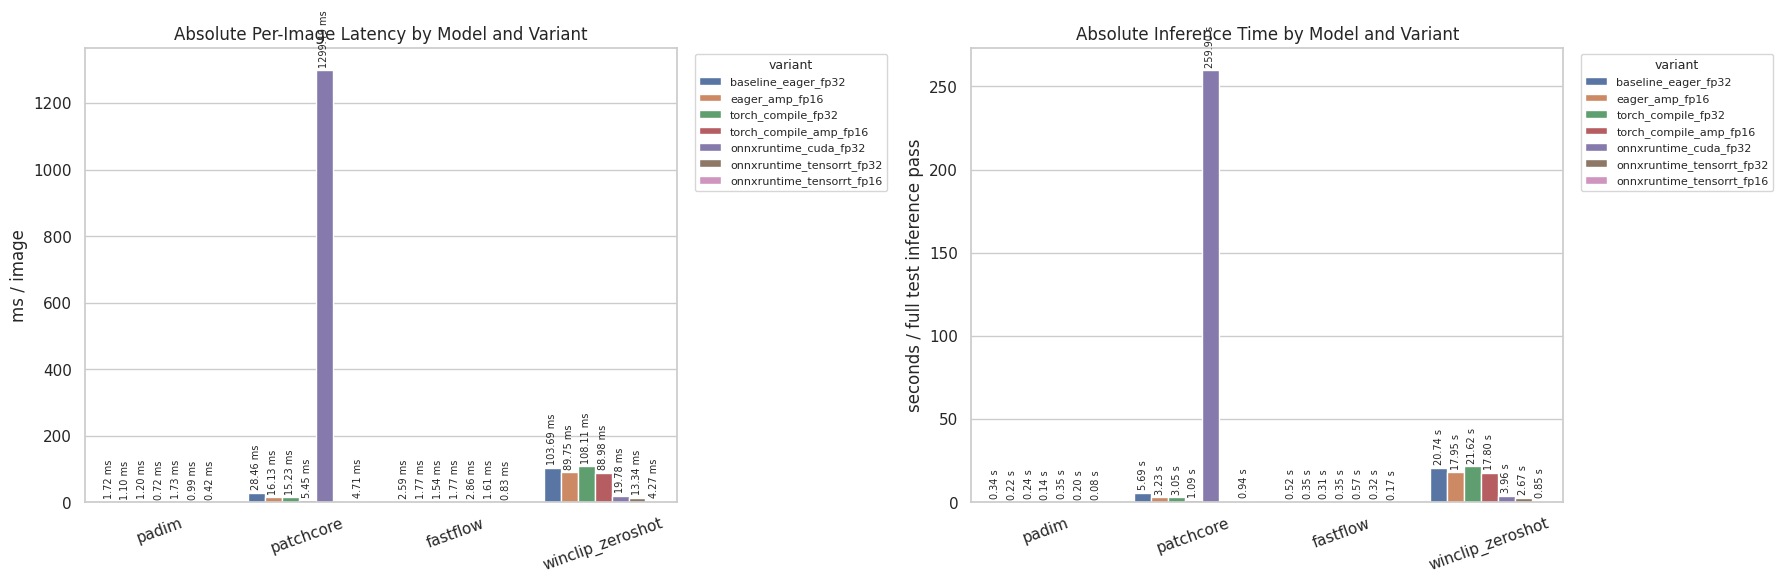

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plot_df = summary.copy()
ax0 = sns.barplot(data=plot_df, x="model", y="latency_ms_per_image", hue="variant", ax=axes[0])
axes[0].set_title("Absolute Per-Image Latency by Model and Variant")
axes[0].set_ylabel("ms / image")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(title="variant", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, title_fontsize=9)

for container in axes[0].containers:
    labels = []
    for bar in container:
        height = bar.get_height()
        labels.append(f"{height:.2f} ms" if np.isfinite(height) else "")
    axes[0].bar_label(container, labels=labels, label_type="edge", padding=2, fontsize=7, rotation=90)

ax1 = sns.barplot(data=plot_df, x="model", y="mean_inference_sec", hue="variant", ax=axes[1])
axes[1].set_title("Absolute Inference Time by Model and Variant")
axes[1].set_ylabel("seconds / full test inference pass")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(title="variant", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, title_fontsize=9)

for container in axes[1].containers:
    labels = []
    for bar in container:
        height = bar.get_height()
        labels.append(f"{height:.2f} s" if np.isfinite(height) else "")
    axes[1].bar_label(container, labels=labels, label_type="edge", padding=2, fontsize=7, rotation=90)

plt.tight_layout()
plt.show()


## Accuracy Impact

The primary practical metric is image-level best F1. Pixel-level best F1 is useful when localization quality matters. Compare absolute F1 values first; a fast variant is not useful if its absolute quality is below the acceptable business threshold.


In [46]:
metric_cols = [
    "model",
    "variant",
    "best_f1",
    "pixel_best_f1",
    "image_auroc",
    "pixel_auroc",
    "best_threshold",
    "pixel_best_threshold",
]
metric_table = summary[metric_cols].sort_values(["model", "best_f1", "pixel_best_f1"], ascending=[True, False, False]).reset_index(drop=True)
metric_table


,model,variant,best_f1,pixel_best_f1,image_auroc,pixel_auroc,best_threshold,pixel_best_threshold
0,fastflow,onnxruntime_cuda_fp32,0.915094,0.202825,0.96800,0.982841,-0.170182,-0.084939
1,fastflow,onnxruntime_tensorrt_fp32,0.910798,0.202524,0.96750,0.983008,-0.173271,-0.081395
2,fastflow,baseline_eager_fp32,0.910798,0.202178,0.96820,0.982965,-0.171262,-0.085058
3,fastflow,torch_compile_fp32,0.910798,0.202122,0.96820,0.982964,-0.169074,-0.085059
4,fastflow,eager_amp_fp16,0.909953,0.203007,0.96690,0.983010,-0.167243,-0.081571
5,fastflow,torch_compile_amp_fp16,0.909953,0.203007,0.96690,0.983010,-0.167243,-0.081571
6,fastflow,onnxruntime_tensorrt_fp16,0.906542,0.202592,0.96910,0.982736,-0.168932,-0.081025
7,padim,torch_compile_fp32,0.893023,0.249025,0.94140,0.989040,63.461359,86.906878
8,padim,baseline_eager_fp32,0.893023,0.249001,0.94140,0.989038,63.464594,86.909963
9,padim,onnxruntime_cuda_fp32,0.893023,0.248753,0.94130,0.989003,62.375399,87.756393


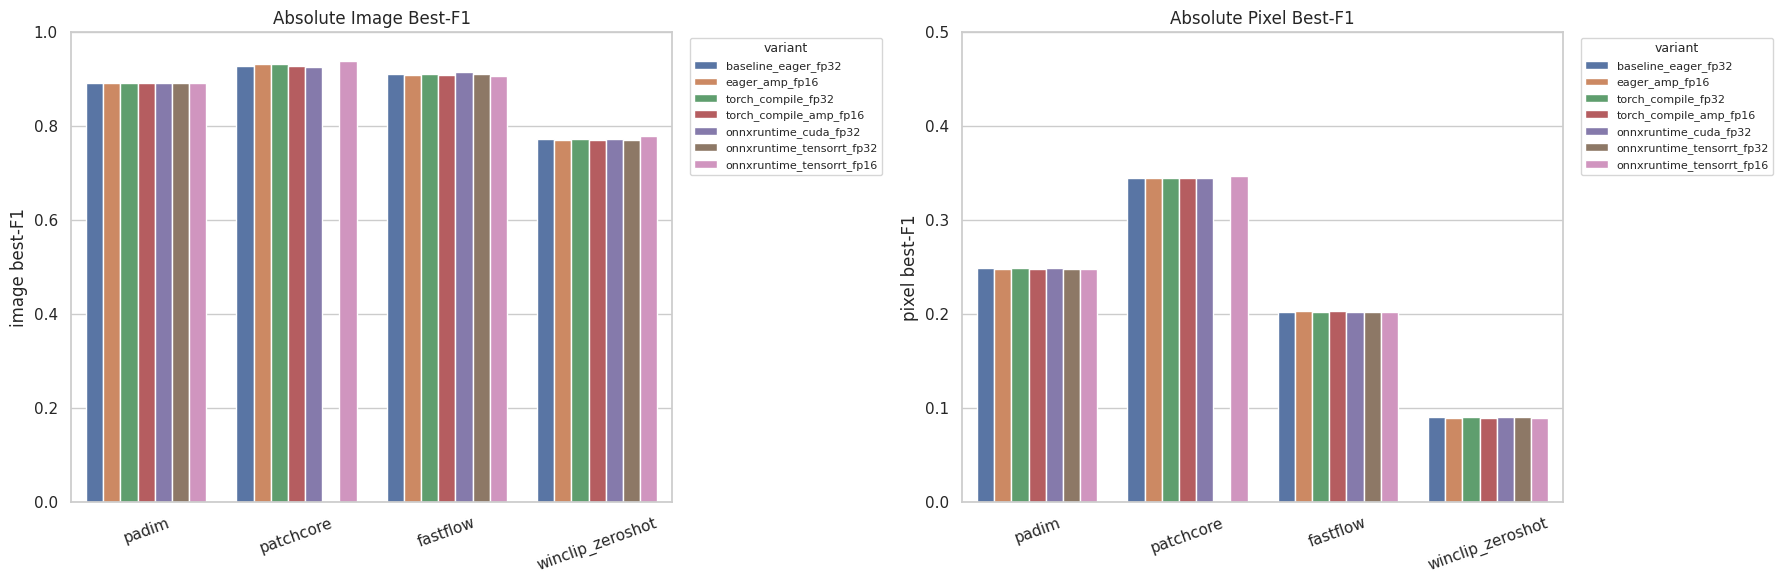

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=summary, x="model", y="best_f1", hue="variant", ax=axes[0])
axes[0].set_title("Absolute Image Best-F1")
axes[0].set_ylabel("image best-F1")
axes[0].set_ylim(0, 1)
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(title="variant", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, title_fontsize=9)

sns.barplot(data=summary, x="model", y="pixel_best_f1", hue="variant", ax=axes[1])
axes[1].set_title("Absolute Pixel Best-F1")
axes[1].set_ylabel("pixel best-F1")
axes[1].set_ylim(0, max(0.5, summary["pixel_best_f1"].max() * 1.15))
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(title="variant", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.show()


## Practical Candidate Selection

A deployment candidate should satisfy absolute quality and absolute per-image latency constraints. Edit the thresholds below to match the target application. The default ranking chooses the lowest-latency variant among candidates that pass the absolute thresholds.


In [48]:
MIN_IMAGE_BEST_F1 = 0.90
MIN_PIXEL_BEST_F1 = 0.20
MAX_LATENCY_MS_PER_IMAGE = 20.0

candidate_df = summary[
    (summary["best_f1"] >= MIN_IMAGE_BEST_F1)
    & (summary["pixel_best_f1"] >= MIN_PIXEL_BEST_F1)
    & (summary["latency_ms_per_image"] <= MAX_LATENCY_MS_PER_IMAGE)
].copy()

best_candidates = (
    candidate_df.sort_values(["model", "latency_ms_per_image", "best_f1", "pixel_best_f1"], ascending=[True, True, False, False])
    .groupby("model", as_index=False)
    .head(1)
    .sort_values("model")
)

best_candidates[[
    "model",
    "variant",
    "latency_ms_per_image",
    "latency_std_ms_per_image",
    "mean_inference_sec",
    "best_f1",
    "pixel_best_f1",
    "image_auroc",
    "pixel_auroc",
]]


,model,variant,latency_ms_per_image,latency_std_ms_per_image,mean_inference_sec,best_f1,pixel_best_f1,image_auroc,pixel_auroc
19,fastflow,onnxruntime_tensorrt_fp16,0.832030,0.457020,0.166406,0.906542,0.202592,0.96910,0.982736
12,patchcore,onnxruntime_tensorrt_fp16,4.710678,0.072265,0.942136,0.940000,0.347202,0.98085,0.992703


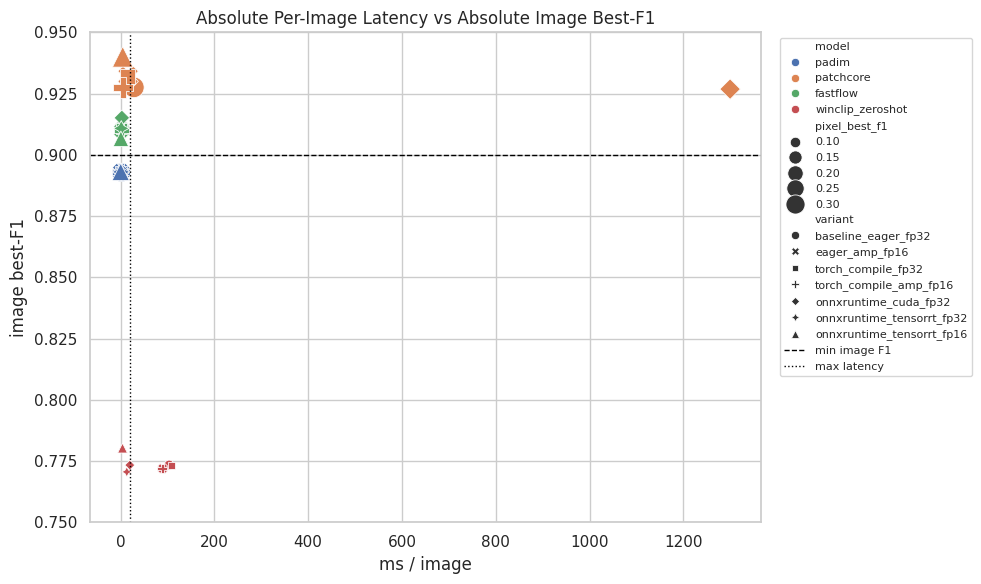

In [49]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = sns.scatterplot(
    data=summary,
    x="latency_ms_per_image",
    y="best_f1",
    hue="model",
    style="variant",
    size="pixel_best_f1",
    sizes=(50, 220),
    ax=ax,
)
ax.axhline(MIN_IMAGE_BEST_F1, color="black", linestyle="--", linewidth=1, label="min image F1")
ax.axvline(MAX_LATENCY_MS_PER_IMAGE, color="black", linestyle=":", linewidth=1, label="max latency")
ax.set_title("Absolute Per-Image Latency vs Absolute Image Best-F1")
ax.set_xlabel("ms / image")
ax.set_ylabel("image best-F1")
ax.set_ylim(0.75, 0.95)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, title_fontsize=9)
plt.tight_layout()
plt.show()


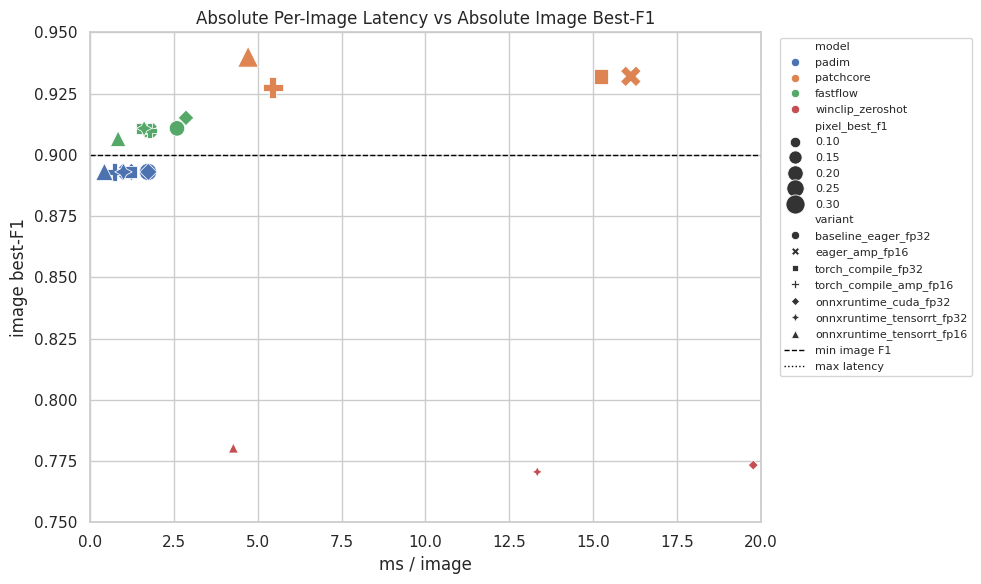

In [53]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = sns.scatterplot(
    data=summary,
    x="latency_ms_per_image",
    y="best_f1",
    hue="model",
    style="variant",
    size="pixel_best_f1",
    sizes=(50, 220),
    ax=ax,
)
ax.axhline(MIN_IMAGE_BEST_F1, color="black", linestyle="--", linewidth=1, label="min image F1")
ax.axvline(MAX_LATENCY_MS_PER_IMAGE, color="black", linestyle=":", linewidth=1, label="max latency")
ax.set_title("Absolute Per-Image Latency vs Absolute Image Best-F1")
ax.set_xlabel("ms / image")
ax.set_ylabel("image best-F1")
ax.set_ylim(0.75, 0.95)
ax.set_xlim(0, 20)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, title_fontsize=9)
plt.tight_layout()
plt.show()


## Timing Stability

Inspect repeat-run variance. TensorRT first runs can include lazy setup effects even after export, so large standard deviation deserves manual review.

In [50]:
timing_rows = []
for _, row in summary.iterrows():
    try:
        timings = ast.literal_eval(row["timings_sec"])
    except Exception:
        timings = []
    for repeat_idx, seconds in enumerate(timings):
        timing_rows.append({"model": row["model"], "variant": row["variant"], "repeat": repeat_idx, "seconds": seconds})

timings_df = pd.DataFrame(timing_rows)
timings_df.head()

,model,variant,repeat,seconds
0,padim,baseline_eager_fp32,0,0.348379
1,padim,baseline_eager_fp32,1,0.342096
2,padim,baseline_eager_fp32,2,0.342930
3,padim,baseline_eager_fp32,3,0.348013
4,padim,baseline_eager_fp32,4,0.343465


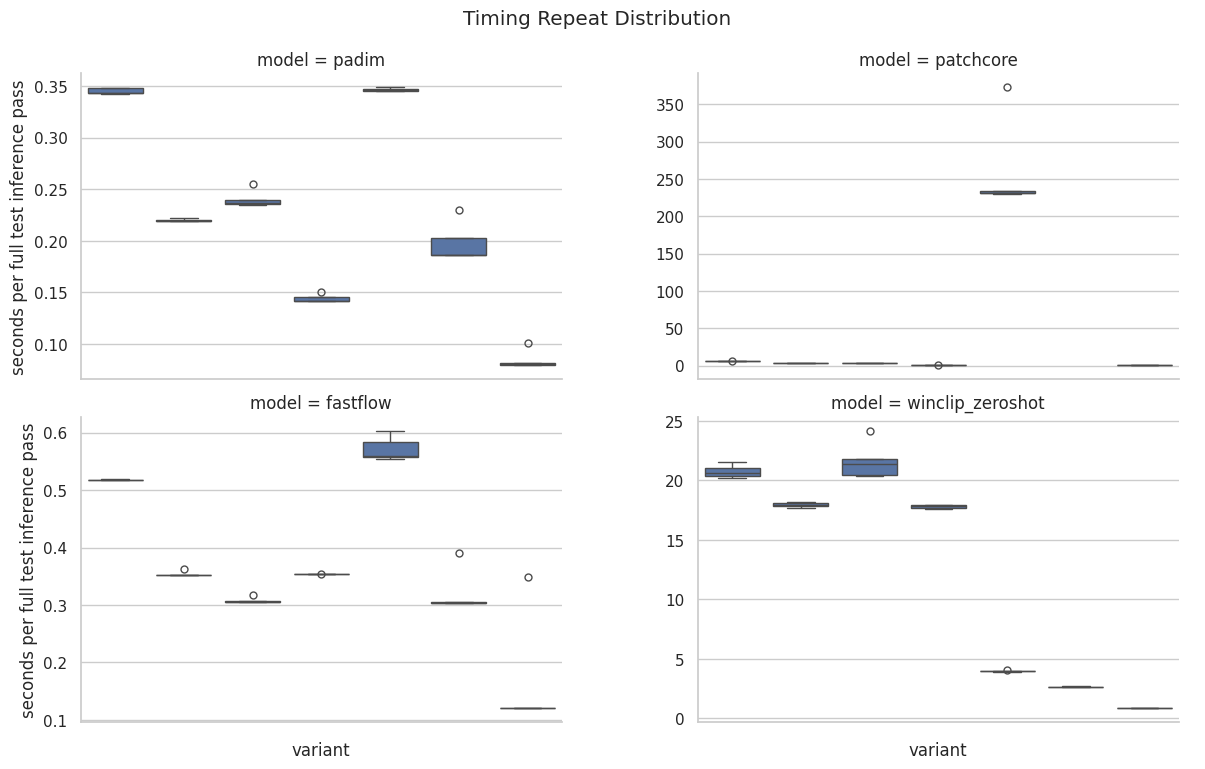

In [51]:
g = sns.catplot(
    data=timings_df,
    kind="box",
    x="variant",
    y="seconds",
    col="model",
    col_wrap=2,
    sharey=False,
    height=4,
    aspect=1.5,
)
g.set_xticklabels(rotation=75, ha="right")
g.set_axis_labels("variant", "seconds per full test inference pass")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Timing Repeat Distribution")
plt.show()

## Notes for Interpretation

- Treat missing or failed TensorRT variants separately; do not compare fallback results as TensorRT.
- `torch_compile_*` can include compile overhead if the benchmark run did not fully amortize it. Prefer repeat timing stability before choosing it.
- ONNX/TensorRT can slightly change scores due to numerical differences. Use absolute F1, absolute per-image latency, and threshold shifts together, not latency alone.
- For final deployment, rerun the selected candidate with production batch size and a larger repeat count.
